In [1]:
# IMPORTS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("TF version:", tf.__version__)

TF version: 2.16.2


In [2]:
# CONFIGURE DIRECTORY, DATA LOCATION

BASE_DIR   = "/Users/nawaza/Desktop/Machine-Learning/Final Project/chest_xray/chest_xray"
TRAIN_DIR  = BASE_DIR + "/train"
VAL_DIR    = BASE_DIR + "/val"
TEST_DIR   = BASE_DIR + "/test"

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 15
LR         = 1e-4

In [3]:
# TRAINING GETS AUGMENTATION, VAL/TEST DOES NOT
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10
)
eval_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_gen   = eval_datagen.flow_from_directory(VAL_DIR,   target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_gen  = eval_datagen.flow_from_directory(TEST_DIR,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

print("Classes:", train_gen.class_indices)  # {NORMAL: 0, PNEUMONIA: 1}

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


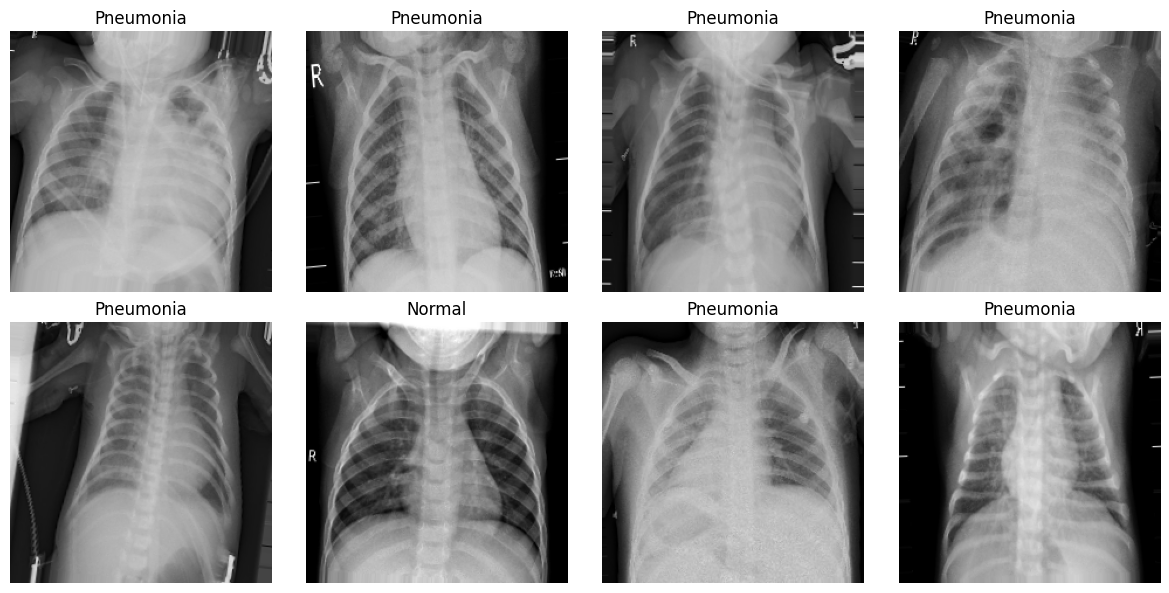

In [4]:
# X RAY IMAGE VISUALIZATION (EXAMPLE)
images, labels = next(train_gen)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i], cmap='gray')
    ax.set_title("Pneumonia" if labels[i] == 1 else "Normal")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# BUILD MODEL W TRANSFER LEARNING

def build_model(backbone='resnet50'):
    # LOAD PRETRAINED BASE, NO TOP LAYER
    if backbone == 'resnet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    else:
        base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # FREEZE BASE, DO NOT OVERWRITE IMAGENET WEIGHTS JUST YET
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')   # BINARY OUTPUT
    ])

    model.compile(
        optimizer=optimizers.Adam(LR),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
    )
    return model, base

resnet_model, resnet_base = build_model('resnet50')
resnet_model.summary()

2026-04-14 20:16:41.245792: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-04-14 20:16:41.245821: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-04-14 20:16:41.245830: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
2026-04-14 20:16:41.245843: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-14 20:16:41.245854: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# TRAIN RESNET50

# STOP EARLY IF VAL_AUC STOPS IMPROVING

early_stop = callbacks.EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max')

# CLASS WEIGHTS SINCE DATASET IS AROUND 72% PNEUMONIA

class_weights = {0: 3.0, 1: 1.0}

history = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15


2026-04-14 20:16:43.935566: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 250ms/step - accuracy: 0.4996 - auc: 0.5120 - loss: 1.2592 - recall: 0.4926 - val_accuracy: 0.5000 - val_auc: 0.8594 - val_loss: 0.6758 - val_recall: 0.0000e+00
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 226ms/step - accuracy: 0.5167 - auc: 0.5481 - loss: 1.1503 - recall: 0.4994 - val_accuracy: 0.5000 - val_auc: 0.8594 - val_loss: 0.6658 - val_recall: 0.0000e+00
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 228ms/step - accuracy: 0.5422 - auc: 0.5674 - loss: 1.1126 - recall: 0.5326 - val_accuracy: 0.5625 - val_auc: 0.8516 - val_loss: 0.6518 - val_recall: 0.8750
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 229ms/step - accuracy: 0.5615 - auc: 0.5981 - loss: 1.0730 - recall: 0.5525 - val_accuracy: 0.8125 - val_auc: 0.8516 - val_loss: 0.6363 - val_recall: 0.7500
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 228ms/step - accuracy: 0.5863 - auc: 0.6399 - loss: 1.0221 - recall: 0.5724 - val_accuracy: 0.6250 - val_auc: 0.8438 - val_loss: 0.6281 - val_recall: 0.875

In [7]:
#FINETUNE RESNET50

# UNFREEZE LAST 30 LAYERS AND RETRAIN AT A LOWER LR
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=optimizers.Adam(LR / 10),  # LOWER LEARNING RATE TO NOT DESTROY PRETRAINED WEIGHTS
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

history_ft = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 281ms/step - accuracy: 0.8349 - auc: 0.9334 - loss: 0.5026 - recall: 0.8132 - val_accuracy: 0.5000 - val_auc: 0.7969 - val_loss: 0.8522 - val_recall: 0.0000e+00
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 261ms/step - accuracy: 0.9266 - auc: 0.9794 - loss: 0.2771 - recall: 0.9226 - val_accuracy: 0.6250 - val_auc: 0.8750 - val_loss: 0.5661 - val_recall: 0.5000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.9339 - auc: 0.9839 - loss: 0.2407 - recall: 0.9290 - val_accuracy: 0.5000 - val_auc: 0.7344 - val_loss: 2.1347 - val_recall: 0.0000e+00
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 273ms/step - accuracy: 0.9396 - auc: 0.9838 - loss: 0.2392 - recall: 0.9347 - val_accuracy: 0.8125 - val_auc: 0.8984 - val_loss: 0.4779 - val_recall: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 272ms/step - accuracy: 0.9450 - auc: 0.9876 - loss: 0.2120 - recall: 0.9419 - val_accuracy: 0.6250 - val_auc: 0.8125 - val_loss: 2.0306 - val_re

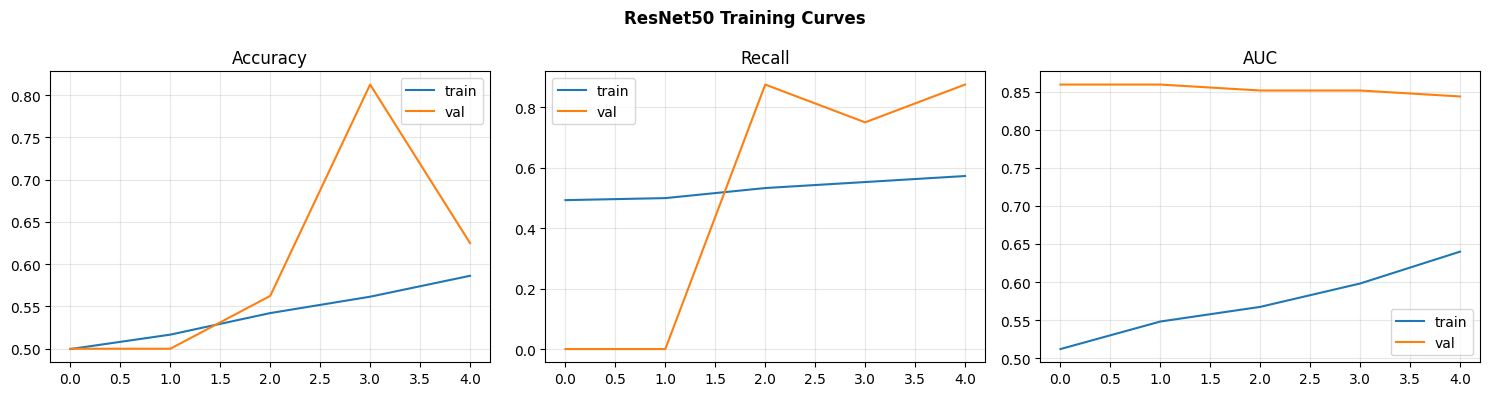

In [8]:
# PLOT TRAINING CURVES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes, ['accuracy', 'recall', 'auc'], ['Accuracy', 'Recall', 'AUC']):
    ax.plot(history.history[metric],       label='train')
    ax.plot(history.history['val_' + metric], label='val')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('ResNet50 Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# EVAL ON TEST SET

# GET PREDICTIONS
test_gen.reset()
y_true  = test_gen.classes
y_proba = resnet_model.predict(test_gen).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step
              precision    recall  f1-score   support

      Normal       0.92      0.75      0.82       234
   Pneumonia       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.87       624
weighted avg       0.88      0.88      0.88       624



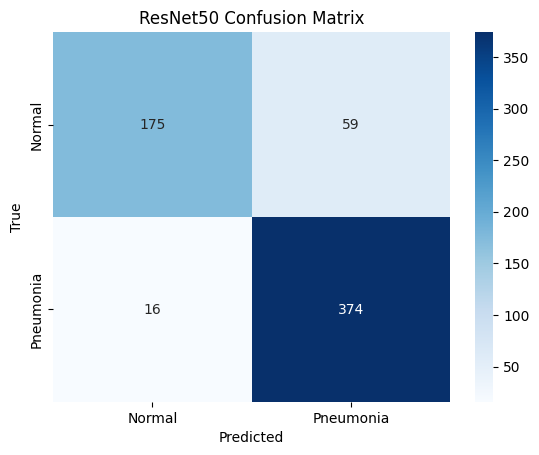

False Negatives (missed pneumonia): 16


In [10]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('ResNet50 Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# false negatives = top-right cell = missed pneumonia cases (clinically worst outcome)
print("False Negatives (missed pneumonia):", cm[1][0])

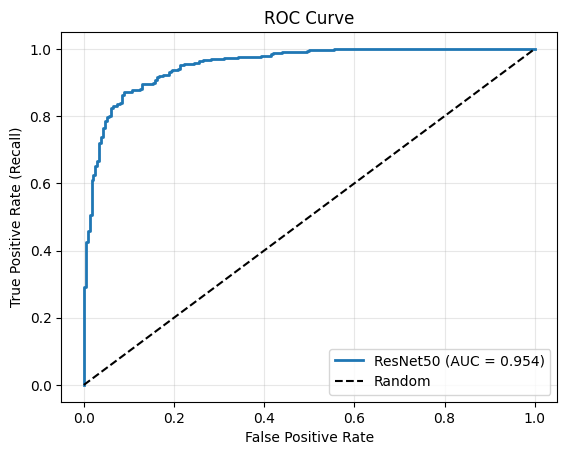

In [11]:
# ROC CURVE

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ResNet50 (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# VGG16 COMPARISON

vgg_model, vgg_base = build_model('vgg16')

vgg_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max')]
)

# evaluate
test_gen.reset()
vgg_preds = (vgg_model.predict(test_gen).flatten() >= 0.5).astype(int)
print(classification_report(y_true, vgg_preds, target_names=['Normal', 'Pneumonia']))

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 269ms/step - accuracy: 0.5638 - auc: 0.5989 - loss: 1.0749 - recall: 0.5597 - val_accuracy: 0.8125 - val_auc: 0.9609 - val_loss: 0.5786 - val_recall: 1.0000
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 276ms/step - accuracy: 0.6869 - auc: 0.7699 - loss: 0.8663 - recall: 0.6782 - val_accuracy: 0.8125 - val_auc: 0.9297 - val_loss: 0.5170 - val_recall: 1.0000
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 276ms/step - accuracy: 0.7828 - auc: 0.8659 - loss: 0.7223 - recall: 0.7708 - val_accuracy: 0.8125 - val_auc: 0.9141 - val_loss: 0.4590 - val_recall: 1.0000
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 281ms/step - accuracy: 0.8217 - auc: 0.9050 - loss: 0.6270 - recall: 0.8108 - val_accuracy: 0.8125 - val_auc: 0.9219 - val_loss: 0.4448 - val_recall: 1.0000
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 274ms/step - accuracy: 0.8476 - auc: 0.9279 - loss: 0.5554 - recall: 0.8356 - val_accuracy: 0.8125 - val_auc: 0.9375 - val_loss: 0.4237 - val_recall: 1.

In [13]:
# TRAIN FROM SCRATCH COMPARISON (NO PRETRAINED WEIGHTS)

def build_scratch_model():
    base = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
    base.trainable = True  # train everything from the start, nothing to protect
    
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(LR),  # full LR since we're starting from scratch
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
    )
    return model

val_gen.reset()

scratch_model = build_scratch_model()

history_scratch = scratch_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights
    # no callbacks — just let it run all 15 epochs
)


# EVAL

test_gen.reset()
scratch_preds = (scratch_model.predict(test_gen).flatten() >= 0.5).astype(int)
print(classification_report(y_true, scratch_preds, target_names=['Normal', 'Pneumonia']))

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 793ms/step - accuracy: 0.8064 - auc: 0.8879 - loss: 0.8380 - recall: 0.8034 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 11.3624 - val_recall: 1.0000
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 126s 777ms/step - accuracy: 0.8530 - auc: 0.9225 - loss: 0.8133 - recall: 0.8459 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 17.4907 - val_recall: 1.0000
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 126s 776ms/step - accuracy: 0.8579 - auc: 0.9281 - loss: 0.7901 - recall: 0.8485 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 11.3789 - val_recall: 1.0000
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 787ms/step - accuracy: 0.8581 - auc: 0.9260 - loss: 0.9190 - recall: 0.8537 - val_accuracy: 0.7500 - val_auc: 0.8281 - val_loss: 1.0235 - val_recall: 0.8750
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.8553 - auc: 0.9134 - loss: 1.0310 - recall: 0.8483 - val_accuracy: 0.8125 - val_auc: 0.8281 - val_loss: 0.9583 - val_re

In [14]:
# FINAL COMPARISON: IMAGENET PRETRAINED VS SCRATCH VS VGG16
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'P-Recall':>10} {'N-Recall':>10}")
print("=" * 55)

# RESNET IMAGENET
resnet_acc  = (y_pred == y_true).mean()
resnet_pr   = (y_pred[y_true==1] == 1).mean()  # PNEUMONIA RECALL
resnet_nr   = (y_pred[y_true==0] == 0).mean()  # NORMAL RECALL

# VGG16
vgg_acc     = (vgg_preds == y_true).mean()
vgg_pr      = (vgg_preds[y_true==1] == 1).mean()
vgg_nr      = (vgg_preds[y_true==0] == 0).mean()

# SCRATCH
scratch_acc = (scratch_preds == y_true).mean()
scratch_pr  = (scratch_preds[y_true==1] == 1).mean()
scratch_nr  = (scratch_preds[y_true==0] == 0).mean()

print(f"{'ResNet50 (ImageNet)':<25} {resnet_acc:>10.3f} {resnet_pr:>10.3f} {resnet_nr:>10.3f}")
print(f"{'VGG16 (ImageNet)':<25} {vgg_acc:>10.3f} {vgg_pr:>10.3f} {vgg_nr:>10.3f}")
print(f"{'ResNet50 (scratch)':<25} {scratch_acc:>10.3f} {scratch_pr:>10.3f} {scratch_nr:>10.3f}")
print("=" * 55)

Model                       Accuracy   P-Recall   N-Recall
ResNet50 (ImageNet)            0.880      0.959      0.748
VGG16 (ImageNet)               0.851      0.864      0.829
ResNet50 (scratch)             0.835      0.823      0.855
